In [ ]:
import torch

print(f"torch version: {torch.__version__}")
print(f"torch cuda version: {torch.version.cuda}")
device = torch.device(torch.cuda.current_device() if torch.cuda.is_available() else "cpu")
print(f"torch device: {device}")
print(f"device name: {torch.cuda.get_device_name(device) if torch.cuda.is_available() else 'cpu'}")

torch version: 2.6.0+cu126
torch cuda version: 12.6
torch device: cuda:0
device name: NVIDIA GeForce RTX 4090 Laptop GPU


In [ ]:
import os

from common import SAVE_MODEL_PATH
from peft import LoraConfig
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj"],
)


se_merge_model = AutoModelForCausalLM.from_pretrained(
    os.path.join(SAVE_MODEL_PATH, "mistral-7b-lora-SE"),
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

se_tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.3")
se_tokenizer.pad_token = se_tokenizer.eos_token

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
import re

import tqdm
from mistral_data import MissionType, MistralData

FuncFindAnswer = lambda text: re.search(r"Answer: (.*)", text).group(1).strip() if re.search(r"Answer: (.*)", text) else "None"

def predict(Model, Tokenizer, MistralData: MistralData) -> list:
    y_pred = []
    test_data = MistralData.test_dataset["train"]
    for i in tqdm.tqdm(range(len(test_data))):
        input_text = test_data["input"][i]
        # print(f"Input: {input_text[:100]}")
        instruction_text = test_data["instruction"][i]
        format_input = f"<s>[INST] {instruction_text} {input_text} [/INST]"
        input_ids = Tokenizer(format_input, return_tensors="pt").input_ids.to(
            device
        )
        attention_mask = Tokenizer(
            format_input, return_tensors="pt"
        ).attention_mask.to(device)
        Model.gradient_checkpointing_enable()
        Model.generation_config.pad_token_id = Tokenizer.pad_token_id
        output = Model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            num_return_sequences=1,
        )
        Model.gradient_checkpointing_enable()
        # print(sequences[0]["generated_text"])
        output_text = Tokenizer.decode(output[0], skip_special_tokens=True)
        # print(f"Output: {output_text}")
        a = FuncFindAnswer(output_text)
        # print(f"Answer: {a}")
        y_pred.append(a)
    return y_pred

y_pred = predict(se_merge_model, se_tokenizer, MistralData(MissionType.SE))
y_test = MistralData(MissionType.SE).df_test["y_true"].tolist()

print(f"y_test: {y_test}")
print(f"y_pred: {y_pred}")

2025-04-18 21:45:01 - INFO - Creating jsonl for Index(['job_id', 'job_title', 'job_summary', 'job_ad_details',
       'classification_name', 'subclassification_name', 'y_true'],
      dtype='object') rows
Creating jsonl: 100%|██████████| 2752/2752 [00:00<00:00, 50191.00it/s]


Generating train split: 0 examples [00:00, ? examples/s]

2025-04-18 21:45:02 - INFO - Creating jsonl for Index(['job_id', 'job_title', 'job_summary', 'job_ad_details',
       'classification_name', 'subclassification_name', 'y_true'],
      dtype='object') rows
Creating jsonl: 100%|██████████| 689/689 [00:00<00:00, 45657.97it/s]


Generating train split: 0 examples [00:00, ? examples/s]

100%|██████████| 689/689 [06:49<00:00,  1.68it/s]
2025-04-18 21:51:52 - INFO - Creating jsonl for Index(['job_id', 'job_title', 'job_summary', 'job_ad_details',
       'classification_name', 'subclassification_name', 'y_true'],
      dtype='object') rows
Creating jsonl: 100%|██████████| 2752/2752 [00:00<00:00, 45966.07it/s]


Generating train split: 0 examples [00:00, ? examples/s]

2025-04-18 21:51:53 - INFO - Creating jsonl for Index(['job_id', 'job_title', 'job_summary', 'job_ad_details',
       'classification_name', 'subclassification_name', 'y_true'],
      dtype='object') rows
Creating jsonl: 100%|██████████| 689/689 [00:00<00:00, 48615.91it/s]


Generating train split: 0 examples [00:00, ? examples/s]

y_test: ['senior', 'experienced', 'entry level', 'senior', 'intermediate', 'experienced', 'experienced', 'entry level', 'entry level', 'experienced', 'senior', 'experienced', 'experienced', 'senior', 'trainee', 'experienced', 'experienced', 'intermediate', 'apprentice', 'entry level', 'entry level', 'entry level', 'experienced', 'experienced', 'experienced', 'experienced', 'graduate', 'senior', 'senior', 'intermediate', 'head', 'senior', 'supervisor', 'lead', 'experienced', 'entry level', 'experienced', 'trainee', 'entry level', 'intermediate', 'experienced', 'entry level', 'experienced', 'lead', 'senior', 'entry level', 'experienced', 'assistant', 'intermediate', 'intermediate', 'experienced assistant', 'assistant', 'intermediate', 'lead', 'entry level', 'experienced', 'senior', 'experienced', 'experienced', 'assistant', 'intermediate', 'entry level', 'senior', 'intermediate', 'experienced', 'experienced', 'experienced', 'junior', 'senior', 'intermediate', 'senior', 'experienced', 'le

In [ ]:
import pandas as pd

df = pd.DataFrame({"y_true": y_test, "y_pred": y_pred})
# df = pd.read_csv("./SE_Mistral_7B_Lora.csv")
df.head()

,y_true,y_pred,similarity
0,senior,senior,1.000000
1,experienced,senior,0.628018
2,entry level,intermediate,0.705405
3,senior,senior,1.000000
4,intermediate,entry level,0.705405


In [ ]:
from sentence_transformers import SentenceTransformer

bge_model = SentenceTransformer("BAAI/bge-small-en-v1.5")

sentences = df[["y_true", "y_pred"]].stack().tolist()
embeddings = bge_model.encode(
    sentences,
    batch_size=128,
    convert_to_tensor=True,
    show_progress_bar=True,
)
true_emb, pred_emb = embeddings[::2], embeddings[1::2]
true_emb = true_emb.to(device)
pred_emb = pred_emb.to(device)
similarity_list = torch.nn.functional.cosine_similarity(true_emb, pred_emb).tolist()

df["similarity"] = similarity_list
df.to_csv("SE_Mistral_7B_Lora.csv", index=False)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

acc = accuracy_score(df["y_true"], df["y_pred"])
print(f"Accuracy: {acc:.4f}")
print(classification_report(df["y_true"], df["y_pred"], zero_division=0))

Accuracy: 0.7068
                             precision    recall  f1-score   support

        1st year apprentice       0.00      0.00      0.00         1
    Chief Executive Officer       0.00      0.00      0.00         0
                   advanced       1.00      1.00      1.00         1
                 apprentice       0.75      1.00      0.86         3
                  assistant       0.77      0.86      0.81        28
        assistant principal       0.00      0.00      0.00         0
                  associate       0.83      0.83      0.83         6
         associate director       0.67      1.00      0.80         2
         associate-director       0.00      0.00      0.00         1
                      cadet       1.00      0.50      0.67         2
                      chief       1.00      0.67      0.80         3
                 consultant       0.00      0.00      0.00         0
                     deputy       0.00      0.00      0.00         1
           deput

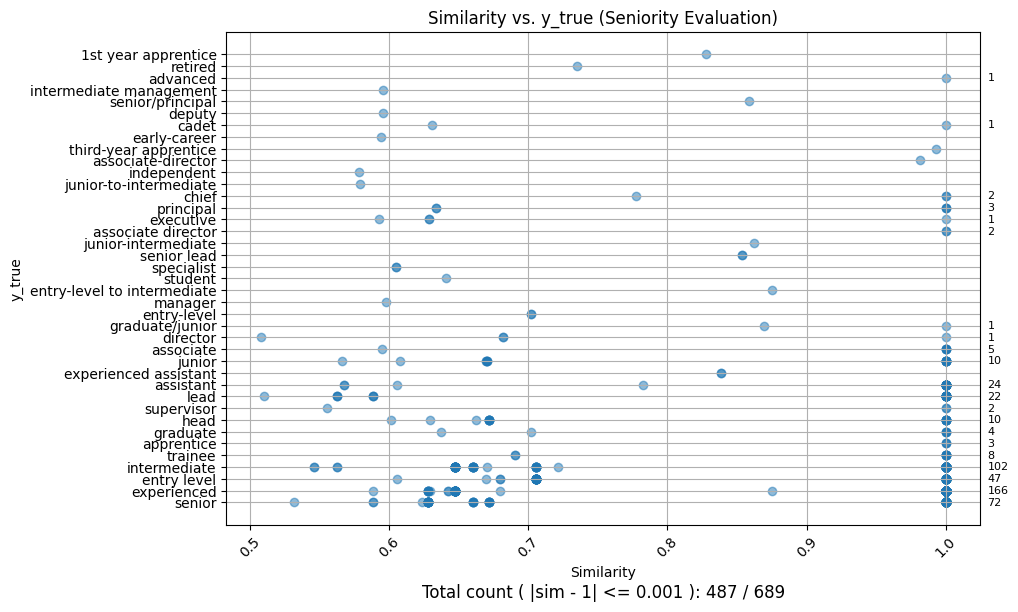

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.transforms import blended_transform_factory

# 1. Define the tolerance for being "near" 1.0
# tol = 0.001 means we consider values in [0.999, 1.001] as "near" 1.0
tol = 0.001

mask = np.abs(df["similarity"] - 1.0) <= tol
df_near1 = df[mask]

counts = df_near1.groupby("y_true").size()

# Create the scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["similarity"], df["y_true"], alpha=0.5)
ax.set_title("Similarity vs. y_true (Seniority Evaluation)")
ax.set_xlabel("Similarity")
ax.set_ylabel("y_true")
ax.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Prepare a blended transform so x uses axes coords (normalized) and y uses data coords
# This allows annotations to appear to the right of the plot at the correct y positions
trans = blended_transform_factory(ax.transAxes, ax.transData)
for y_val, cnt in counts.items():
    ax.text(
        1.01,
        y_val,
        f"{cnt}",
        transform=trans,
        va="center",
        fontsize=8,
        # bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.3)
    )

# Add a text box with the total count of values within the tolerance
total_count = counts.sum()
ax.text(
    0.5,
    -0.12,
    f"Total count ( |sim - 1| <= {tol} ): {total_count} / {len(df)}",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=12,
    # bbox=dict(boxstyle="round,pad=0.3", fc="lightblue", alpha=0.3)
)

plt.show()